# C3 (UNSW-NB15): Kernel Geometry & Classification Performance — Phase 5 Final

## 1. Bối cảnh Khoa học (Generalization Test — Final Phase)

C2 đã chứng minh: ZZFeatureMap có expressibility cao trên UNSW (KL=0.022), entanglement entropy phân biệt Attack vs Normal có ý nghĩa thống kê (p=1.4e-8). Câu hỏi cuối cùng:

> *Khi đưa quantum kernel vào pipeline phân loại thực tế (SVC), nó có vượt qua các classical kernel (RBF/Poly/Linear) không? Và Kernel Target Alignment (KTA) cho ta tín hiệu gì về ưu thế quantum?*

## 2. Phương pháp luận

| Phép đo | Định nghĩa | Kỳ vọng QSVM |
|---------|-----------|--------------|
| **KTA** (Cristianini 2002) | $\mathrm{KTA}(K, y) = \langle K, yy^\top \rangle_F / (\|K\|_F \cdot \|yy^\top\|_F)$ với $y \in \{-1,+1\}^n$ | KTA cao = kernel structure khớp với label structure |
| **F1-macro** | Trung bình F1 trên 2 lớp Normal/Attack | Đo balance, không bị ảnh hưởng bởi class imbalance |
| **Support Vector count** | Số mẫu nằm trên/trong margin | Ít SV = simpler boundary; Nhiều SV = richer boundary (có thể là dấu hiệu QSVM khai thác feature-space phức tạp hơn) |
| **McNemar test** | Paired $\chi^2$ trên cặp dự đoán đúng/sai | Test thống kê chuẩn để so sánh 2 classifier trên cùng test set |

## 3. Tối ưu hóa Hiệu năng

Thay vì `FidelityQuantumKernel` (gọi sampler primitive cho mỗi cặp → $O(N^2)$ tới vài giờ với $N=500$), ta dùng **statevector matrix-product trick** đã chứng minh ở Phase 4:

```
states_train = build_statevectors(X_train)   # (500, 16) complex
states_test  = build_statevectors(X_test)    # (300, 16) complex
K_train      = |states_train.conj() @ states_train.T|^2   # (500, 500)
K_test       = |states_test.conj()  @ states_train.T|^2   # (300, 500) cross-kernel
```

Tổng thời gian: **<30 giây** thay vì 2-3 giờ.

## 4. Cấu trúc Notebook

| § | Nội dung |
|---|----------|
| 5 | Tải UNSW PCA4D + stratified subsample (N_train=500, N_test=300) |
| 6 | Tính kernel ZZ (train-train, test-train) via statevector |
| 7 | Tính kernel classical (linear, poly2, RBF) via sklearn |
| 8 | KTA cho 4 kernel + ranking |
| 9 | Train QSVM + 3 classical SVC, đo F1-macro / Accuracy / SV counts |
| 10 | McNemar test QSVM vs RBF + Cohen's d trên decision margin |
| 11 | Heatmap QSVM vs RBF (sorted by class) |
| 12 | Lưu CSV + JSON + summary cross-dataset |

Output ghi vào `../reports_unsw/` (KHÔNG ghi đè plots NSL-KDD).


In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

warnings.filterwarnings('ignore')

# Qiskit (2.3.0): API chuc nang lowercase
from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector

# Scikit-learn
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.metrics.pairwise import linear_kernel, polynomial_kernel, rbf_kernel
from sklearn.model_selection import train_test_split

# Khoa hoc + thong ke
from scipy.stats import binomtest

# ── Hang so toan cuc ────────────────────────────────────────────────
N_QUBITS         = 4               # Rang buoc phan cung NISQ
HILBERT_DIM      = 2 ** N_QUBITS   # = 16
N_TRAIN          = 500             # Stratified train subsample (memory-safe)
N_TEST           = 300             # Stratified test subsample
ZZ_REPS          = 2               # Cau hinh ZZ chinh
ZZ_ENTANGLEMENT  = "full"         # Tat ca 6 cap qubit
SVC_C            = 1.0             # C dong nhat cho moi kernel (fairness)
POLY_DEGREE      = 2               # Bac da thuc cho polynomial kernel
RANDOM_STATE     = 42

# Duong dan I/O
TRAIN_PARQUET    = "../data/unsw_nb15/processed_data/UNSW_Train_PCA4D.parquet"
TEST_PARQUET     = "../data/unsw_nb15/processed_data/UNSW_Test_PCA4D.parquet"
REPORTS_DIR      = "../reports_unsw"
RESULTS_CSV      = os.path.join(REPORTS_DIR, "c3_unsw_kernel_comparison.csv")
RESULTS_JSON     = os.path.join(REPORTS_DIR, "c3_unsw_results.json")
HEATMAP_PNG      = os.path.join(REPORTS_DIR, "unsw_c3_kernel_matrix.png")
KTA_BAR_PNG      = os.path.join(REPORTS_DIR, "unsw_c3_kta_comparison.png")
os.makedirs(REPORTS_DIR, exist_ok=True)

LABEL_COLS       = ["label_binary", "label_multiclass", "attack_category"]

print("Import hoan tat (Qiskit 2.3.0).")
print(f"Cau hinh: N_TRAIN={N_TRAIN}, N_TEST={N_TEST}, "
      f"ZZ reps={ZZ_REPS}, entanglement={ZZ_ENTANGLEMENT!r}, C={SVC_C}")


Import hoan tat (Qiskit 2.3.0).
Cau hinh: N_TRAIN=500, N_TEST=300, ZZ reps=2, entanglement='full', C=1.0


## 5. Tải dữ liệu UNSW-NB15 PCA4D + Stratified Subsample

Dữ liệu đầu vào đã sẵn sàng cho QSVM (Phase 1-3 đã hoàn tất):
- `UNSW_Train_PCA4D.parquet` (175,341 × 7) — 4 PCs trong [0, π] + 3 nhãn
- `UNSW_Test_PCA4D.parquet` (82,332 × 7)

**Tại sao subsample N_train=500, N_test=300?**
- $K_{\text{train}}$ là $500 \times 500 = 250{,}000$ ô
- $K_{\text{test} \times \text{train}}$ là $300 \times 500 = 150{,}000$ ô
- SVC training trên kernel precomputed: $O(N_{\text{train}}^3)$ trong worst case → 500 là sweet spot (xong < 1s)
- Quy mô này đủ để KTA + F1 hội tụ thống kê và McNemar test có power


In [2]:
print(f"Dang tai {TRAIN_PARQUET}...")
df_train = pd.read_parquet(TRAIN_PARQUET)
print(f"  Shape: {df_train.shape}")
print(f"Dang tai {TEST_PARQUET}...")
df_test = pd.read_parquet(TEST_PARQUET)
print(f"  Shape: {df_test.shape}")

feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]
assert len(feature_cols) == N_QUBITS, \
    f"Mong doi {N_QUBITS} PC, nhan duoc {len(feature_cols)}: {feature_cols}"

X_train_full = df_train[feature_cols].values.astype(np.float64)
y_train_full = df_train["label_binary"].values.astype(int)
X_test_full  = df_test[feature_cols].values.astype(np.float64)
y_test_full  = df_test["label_binary"].values.astype(int)

print(f"\nFeature columns: {feature_cols}")
print(f"X_train_full: {X_train_full.shape}, range=[{X_train_full.min():.4f}, {X_train_full.max():.4f}]")
print(f"X_test_full:  {X_test_full.shape},  range=[{X_test_full.min():.4f}, {X_test_full.max():.4f}]")

# Stratified subsample (giu nguyen ti le binary)
def stratified_subsample(X, y, n_target, seed=RANDOM_STATE):
    """Lay mau phan tang theo binary label."""
    if n_target >= len(y):
        return X.copy(), y.copy()
    discard_frac = 1.0 - n_target / len(y)
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=discard_frac, stratify=y, random_state=seed
    )
    # Sap xep theo nhan: Normal truoc, Attack sau (de heatmap co block-structure)
    sort_idx = np.argsort(y_sub)
    return X_sub[sort_idx], y_sub[sort_idx]


X_train, y_train = stratified_subsample(X_train_full, y_train_full, N_TRAIN)
X_test,  y_test  = stratified_subsample(X_test_full,  y_test_full,  N_TEST)

n_tr_normal = int((y_train == 0).sum()); n_tr_attack = int((y_train == 1).sum())
n_te_normal = int((y_test  == 0).sum()); n_te_attack = int((y_test  == 1).sum())

print(f"\nStratified subsample (seed={RANDOM_STATE}, sorted by class):")
print(f"  Train: N={N_TRAIN}  Normal={n_tr_normal} ({n_tr_normal/N_TRAIN:.1%}) | "
      f"Attack={n_tr_attack} ({n_tr_attack/N_TRAIN:.1%})")
print(f"  Test : N={N_TEST}  Normal={n_te_normal} ({n_te_normal/N_TEST:.1%}) | "
      f"Attack={n_te_attack} ({n_te_attack/N_TEST:.1%})")
print(f"  Range train: [{X_train.min():.4f}, {X_train.max():.4f}]  (ky vong [0, pi])")
print(f"  Range test:  [{X_test.min():.4f},  {X_test.max():.4f}]")
assert X_train.min() >= 0.0 and X_train.max() <= np.pi + 1e-6


Dang tai ../data/unsw_nb15/processed_data/UNSW_Train_PCA4D.parquet...
  Shape: (175341, 7)
Dang tai ../data/unsw_nb15/processed_data/UNSW_Test_PCA4D.parquet...
  Shape: (82332, 7)

Feature columns: ['PC1', 'PC2', 'PC3', 'PC4']
X_train_full: (175341, 4), range=[0.0000, 3.1416]
X_test_full:  (82332, 4),  range=[0.0000, 3.1416]

Stratified subsample (seed=42, sorted by class):
  Train: N=500  Normal=160 (32.0%) | Attack=340 (68.0%)
  Test : N=300  Normal=135 (45.0%) | Attack=165 (55.0%)
  Range train: [0.0170, 3.1416]  (ky vong [0, pi])
  Range test:  [0.0160,  3.1155]


## 6. Tính Quantum Kernel — Statevector Matrix-Product Trick

### 6.1 Lý thuyết

Với $n=4$ qubit, không gian Hilbert có chiều $d = 2^n = 16$. Mỗi điểm dữ liệu $x \in [0, \pi]^4$ ánh xạ thành một vector $|\psi(x)\rangle \in \mathbb{C}^{16}$ qua ZZFeatureMap. Kernel:
$$K(x_i, x_j) = |\langle \psi(x_i) | \psi(x_j) \rangle|^2$$

Thay vì gọi `FidelityQuantumKernel.evaluate()` từng cặp (gây ~1-3 giờ overhead với sampler primitive), ta:

1. Tính trước **800 statevector** (500 train + 300 test) — mỗi cái ~0.005s → tổng ~4-8s
2. Kernel matrix $= |S \cdot S^*|^2$ qua phép nhân ma trận (BLAS optimized) — vài chục mili-giây

**Speedup ~360×** so với reference NSL-KDD pipeline.

### 6.2 Chi tiết: cross-kernel (test × train)

Với SVC dự đoán cần kernel matrix dạng $K_{\text{test}, \text{train}} \in \mathbb{R}^{N_{\text{test}} \times N_{\text{train}}}$:
$$(K_{\text{test}, \text{train}})_{ij} = |\langle \psi(x^{\text{test}}_i) | \psi(x^{\text{train}}_j) \rangle|^2$$

Công thức cùng dạng — chỉ cần `states_test.conj() @ states_train.T`.

In [3]:
def build_statevectors(X, reps=ZZ_REPS, entanglement=ZZ_ENTANGLEMENT):
    """Tinh tat ca |psi(x)> cho cac mau X. Tra ve mang phuc (N, 16).

    Toi uu: tao circuit base mot lan, chi rebind parameters cho moi mau.
    """
    base_circ = zz_feature_map(N_QUBITS, reps=reps, entanglement=entanglement)
    params    = list(base_circ.parameters)
    N         = len(X)
    states    = np.zeros((N, HILBERT_DIM), dtype=np.complex128)
    for i, x in enumerate(X):
        bound = base_circ.assign_parameters(dict(zip(params, x)))
        states[i] = np.asarray(Statevector(bound).data)
    return states


def quantum_kernel_from_states(states_a, states_b=None):
    """Kernel ZZ tu mang statevector.

    states_a, states_b: mang (Na, d), (Nb, d). Neu b la None -> tu kernel.
    Tra ve K (Na, Nb) thuc, gia tri trong [0, 1].
    """
    if states_b is None:
        states_b = states_a
    overlap = states_a.conj() @ states_b.T
    return np.abs(overlap) ** 2


print("=== Quantum Kernel Computation (Statevector Trick) ===\n")

t0 = time.time()
states_train = build_statevectors(X_train)
dt_tr = time.time() - t0
print(f"  Statevectors train: {states_train.shape}  ({dt_tr:.2f}s)")

t0 = time.time()
states_test = build_statevectors(X_test)
dt_te = time.time() - t0
print(f"  Statevectors test:  {states_test.shape}  ({dt_te:.2f}s)")

t0 = time.time()
K_train_train = quantum_kernel_from_states(states_train)
dt_kt = time.time() - t0
print(f"  K_train_train:      {K_train_train.shape}  ({dt_kt*1000:.1f}ms)")

t0 = time.time()
K_test_train = quantum_kernel_from_states(states_test, states_train)
dt_kx = time.time() - t0
print(f"  K_test_train:       {K_test_train.shape}  ({dt_kx*1000:.1f}ms)")

print(f"\n  Tong thoi gian quantum kernel: {dt_tr + dt_te + dt_kt + dt_kx:.2f}s")

# Sanity check
print(f"\nSanity checks:")
print(f"  trace(K_train_train) = {np.trace(K_train_train):.4f}  (ky vong = N_TRAIN = {N_TRAIN})")
print(f"  K_train symmetric:    {np.allclose(K_train_train, K_train_train.T)}")
print(f"  K_train min/max:      [{K_train_train.min():.4f}, {K_train_train.max():.4f}]")
print(f"  K_test_train min/max: [{K_test_train.min():.4f}, {K_test_train.max():.4f}]")
assert np.isclose(np.trace(K_train_train), N_TRAIN, atol=1e-6), "Diagonal khong la 1 - sai trang thai"
assert np.allclose(K_train_train, K_train_train.T, atol=1e-10), "Train kernel khong doi xung"


=== Quantum Kernel Computation (Statevector Trick) ===



  Statevectors train: (500, 16)  (0.51s)


  Statevectors test:  (300, 16)  (0.35s)
  K_train_train:      (500, 500)  (6.2ms)
  K_test_train:       (300, 500)  (2.0ms)

  Tong thoi gian quantum kernel: 0.87s

Sanity checks:
  trace(K_train_train) = 500.0000  (ky vong = N_TRAIN = 500)
  K_train symmetric:    True
  K_train min/max:      [0.0000, 1.0000]
  K_test_train min/max: [0.0000, 1.0000]


## 7. Tính Kernel Cổ điển + Kernel Target Alignment (KTA)

**Cấu hình classical kernels (theo sklearn defaults):**
- **Linear:** $K(x_i, x_j) = x_i^\top x_j$
- **Polynomial degree 2:** $K(x_i, x_j) = (\gamma \cdot x_i^\top x_j + 0)^2$, với $\gamma = 1/n_{\text{features}} = 0.25$
- **RBF:** $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$, với $\gamma = 1/(n_{\text{features}} \cdot \mathrm{Var}(X)) = $ "scale"

**KTA (Cristianini et al., 2002 — UNCENTERED, thống nhất với reference NSL-KDD):**
$$\mathrm{KTA}(K, y) = \frac{\langle K, yy^\top \rangle_F}{\|K\|_F \cdot \|yy^\top\|_F}$$
trong đó $y \in \{-1, +1\}^n$ (chuyển đổi từ label binary $\{0, 1\}$).

**Diễn giải:**
- KTA cao → kernel structure phù hợp với label structure → SVC dễ học
- KTA thấp → kernel cấu trúc xa label → SVC phải làm việc cật lực qua C parameter
- KTA chỉ là **thước đo gián tiếp**; F1-macro mới là chỉ số phân loại thực sự

In [4]:
# Tinh kernel matrix classical tren X_train (dung cho KTA)
print("=== Classical Kernels — Train Gram Matrix ===\n")

t0 = time.time()
K_linear_train = linear_kernel(X_train)
print(f"  K_linear: {K_linear_train.shape}  ({(time.time()-t0)*1000:.1f}ms)")

t0 = time.time()
gamma_poly = 1.0 / N_QUBITS
K_poly_train = polynomial_kernel(X_train, degree=POLY_DEGREE, gamma=gamma_poly, coef0=0)
print(f"  K_poly degree={POLY_DEGREE}, gamma={gamma_poly}: "
      f"{K_poly_train.shape}  ({(time.time()-t0)*1000:.1f}ms)")

t0 = time.time()
gamma_rbf = 1.0 / (N_QUBITS * X_train.var())
K_rbf_train = rbf_kernel(X_train, gamma=gamma_rbf)
print(f"  K_rbf gamma={gamma_rbf:.4f} (scale): "
      f"{K_rbf_train.shape}  ({(time.time()-t0)*1000:.1f}ms)")


# ── Kernel Target Alignment (Cristianini formulation) ──────────────
def kernel_target_alignment(K, y):
    """KTA = <K, yy'>_F / (||K||_F * ||yy'||_F).

    y: binary {0, 1} -> {-1, +1} truoc khi tinh outer product.
    """
    yy = y.astype(np.float64).copy()
    yy[yy == 0] = -1.0
    Y   = np.outer(yy, yy)
    num = float(np.sum(K * Y))
    den = float(np.linalg.norm(K, 'fro') * np.linalg.norm(Y, 'fro'))
    return float(num / den) if den > 1e-12 else 0.0


# Tinh KTA cho 4 kernel
kta_scores = {
    'quantum': kernel_target_alignment(K_train_train, y_train),
    'rbf':     kernel_target_alignment(K_rbf_train,   y_train),
    'poly':    kernel_target_alignment(K_poly_train,  y_train),
    'linear':  kernel_target_alignment(K_linear_train, y_train),
}

print("\n=== Kernel Target Alignment Ranking ===")
print(f"{'Kernel':>10}  {'KTA':>10}  {'Rank':>6}")
print('-' * 32)
sorted_kta = sorted(kta_scores.items(), key=lambda kv: kv[1], reverse=True)
for rank, (lbl, kta) in enumerate(sorted_kta, 1):
    flag = ' <-- BEST' if rank == 1 else ''
    print(f"{lbl:>10}  {kta:>10.6f}  {rank:>6}{flag}")

best_kernel_kta = sorted_kta[0][0]
qsvm_rank = next(i for i, (lbl, _) in enumerate(sorted_kta, 1) if lbl == 'quantum')
print(f"\nQSVM rank by KTA: #{qsvm_rank}/4")


=== Classical Kernels — Train Gram Matrix ===

  K_linear: (500, 500)  (1.0ms)
  K_poly degree=2, gamma=0.25: (500, 500)  (1.0ms)
  K_rbf gamma=0.2705 (scale): (500, 500)  (3.0ms)

=== Kernel Target Alignment Ranking ===
    Kernel         KTA    Rank
--------------------------------
       rbf    0.196979       1 <-- BEST
   quantum    0.159415       2
    linear    0.081626       3
      poly    0.045054       4

QSVM rank by KTA: #2/4


## 8. Train SVC (QSVM precomputed + Classical) — F1 / Accuracy / SV Counts

**Cấu hình:**
- $C = 1.0$ thống nhất cho mọi kernel (fairness — không tune để giữ comparison clean)
- Không dùng `class_weight='balanced'` (giống reference NSL-KDD)
- `random_state` cố định cho reproducibility

In [5]:
print("=== Training SVC Models ===\n")

models = {}
metrics = {}

# ── 1. QSVM (precomputed quantum kernel) ────────────────────────────
print("[1/4] QSVM (kernel='precomputed', ZZFeatureMap)")
t0 = time.time()
svc_q = SVC(kernel='precomputed', C=SVC_C, random_state=RANDOM_STATE)
svc_q.fit(K_train_train, y_train)
y_pred_q = svc_q.predict(K_test_train)
df_q     = svc_q.decision_function(K_test_train)
dt_q = time.time() - t0
metrics['quantum'] = {
    'f1':            f1_score(y_test, y_pred_q, average='macro'),
    'accuracy':      accuracy_score(y_test, y_pred_q),
    'precision':     precision_score(y_test, y_pred_q, average='macro'),
    'recall':        recall_score(y_test, y_pred_q, average='macro'),
    'n_sv':          int(svc_q.support_.shape[0]),
    'n_sv_class':    svc_q.n_support_.tolist(),
    'sv_ratio':      float(svc_q.support_.shape[0] / N_TRAIN),
    'fit_time_s':    float(dt_q),
    'kta':           kta_scores['quantum'],
    'y_pred':        y_pred_q.tolist(),
    'decision_func': df_q.tolist(),
}
models['quantum'] = svc_q
print(f"  F1-macro={metrics['quantum']['f1']:.4f}  "
      f"Acc={metrics['quantum']['accuracy']:.4f}  "
      f"n_SV={metrics['quantum']['n_sv']} ({metrics['quantum']['sv_ratio']:.1%})  "
      f"({dt_q:.2f}s)")

# ── 2-4. Classical SVC ──────────────────────────────────────────────
classical_specs = [
    ('linear', dict(kernel='linear', C=SVC_C, random_state=RANDOM_STATE)),
    ('poly',   dict(kernel='poly',   C=SVC_C, degree=POLY_DEGREE, gamma='scale',
                    coef0=0, random_state=RANDOM_STATE)),
    ('rbf',    dict(kernel='rbf',    C=SVC_C, gamma='scale', random_state=RANDOM_STATE)),
]

for idx, (label, spec) in enumerate(classical_specs, start=2):
    print(f"[{idx}/4] Classical SVC ({label}, gamma={spec.get('gamma', '-')})")
    t0 = time.time()
    svc = SVC(**spec)
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    df_x   = svc.decision_function(X_test)
    dt = time.time() - t0
    metrics[label] = {
        'f1':            f1_score(y_test, y_pred, average='macro'),
        'accuracy':      accuracy_score(y_test, y_pred),
        'precision':     precision_score(y_test, y_pred, average='macro'),
        'recall':        recall_score(y_test, y_pred, average='macro'),
        'n_sv':          int(svc.support_.shape[0]),
        'n_sv_class':    svc.n_support_.tolist(),
        'sv_ratio':      float(svc.support_.shape[0] / N_TRAIN),
        'fit_time_s':    float(dt),
        'kta':           kta_scores[label],
        'y_pred':        y_pred.tolist(),
        'decision_func': df_x.tolist(),
    }
    models[label] = svc
    print(f"  F1-macro={metrics[label]['f1']:.4f}  "
          f"Acc={metrics[label]['accuracy']:.4f}  "
          f"n_SV={metrics[label]['n_sv']} ({metrics[label]['sv_ratio']:.1%})  "
          f"({dt:.2f}s)")

# ── Bang tom tat ────────────────────────────────────────────────────
print("\n=== Bang Tom Tat — KTA + Performance ===")
print(f"{'Kernel':>10}  {'KTA':>9}  {'F1-macro':>9}  {'Accuracy':>9}  {'#SV':>5}  {'SV%':>6}")
print('-' * 62)
for lbl in ['quantum', 'rbf', 'poly', 'linear']:
    m = metrics[lbl]
    print(f"{lbl:>10}  {m['kta']:>9.4f}  {m['f1']:>9.4f}  {m['accuracy']:>9.4f}  "
          f"{m['n_sv']:>5d}  {m['sv_ratio']:>6.1%}")


=== Training SVC Models ===

[1/4] QSVM (kernel='precomputed', ZZFeatureMap)
  F1-macro=0.7505  Acc=0.7567  n_SV=244 (48.8%)  (0.00s)
[2/4] Classical SVC (linear, gamma=-)
  F1-macro=0.7441  Acc=0.7467  n_SV=255 (51.0%)  (0.00s)
[3/4] Classical SVC (poly, gamma=scale)
  F1-macro=0.7649  Acc=0.7667  n_SV=239 (47.8%)  (0.00s)
[4/4] Classical SVC (rbf, gamma=scale)
  F1-macro=0.7649  Acc=0.7667  n_SV=251 (50.2%)  (0.01s)

=== Bang Tom Tat — KTA + Performance ===
    Kernel        KTA   F1-macro   Accuracy    #SV     SV%
--------------------------------------------------------------
   quantum     0.1594     0.7505     0.7567    244   48.8%
       rbf     0.1970     0.7649     0.7667    251   50.2%
      poly     0.0451     0.7649     0.7667    239   47.8%
    linear     0.0816     0.7441     0.7467    255   51.0%


## 9. McNemar Test (QSVM vs RBF) + Cohen's d on Decision Margin

**McNemar's test** (paired, exact binomial form):
- $b$ = số mẫu QSVM sai mà RBF đúng
- $c$ = số mẫu QSVM đúng mà RBF sai
- Null hypothesis: $b = c$ (hai classifier có error rate tương đương)
- Test: $X \sim \text{Binomial}(b+c, 0.5)$, p-value 2-sided

**Cohen's d on |decision function|:** đo độ "tự tin" của boundary giữa QSVM và RBF.

In [6]:
# ── McNemar test: QSVM vs RBF ───────────────────────────────────────
y_pred_q   = np.array(metrics['quantum']['y_pred'])
y_pred_rbf = np.array(metrics['rbf']['y_pred'])

q_correct   = (y_pred_q   == y_test)
rbf_correct = (y_pred_rbf == y_test)
b = int(np.sum((~q_correct) & rbf_correct))   # QSVM sai, RBF dung
c = int(np.sum(q_correct & (~rbf_correct)))    # QSVM dung, RBF sai
n_disagree = b + c

print("=== McNemar Test: QSVM vs RBF ===\n")
print(f"  Both correct      : {int(np.sum(q_correct & rbf_correct)):>4d}")
print(f"  Both wrong        : {int(np.sum(~q_correct & ~rbf_correct)):>4d}")
print(f"  QSVM wrong, RBF ok: {b:>4d}  (b)")
print(f"  QSVM ok, RBF wrong: {c:>4d}  (c)")
print(f"  Total disagreement: {n_disagree:>4d}")

if n_disagree > 0:
    binom_res = binomtest(min(b, c), n=n_disagree, p=0.5)
    p_mcnemar = float(binom_res.pvalue)
else:
    p_mcnemar = 1.0
print(f"\n  McNemar p-value (exact binomial, 2-sided) = {p_mcnemar:.6g}")

if p_mcnemar < 0.05:
    if metrics['quantum']['accuracy'] > metrics['rbf']['accuracy']:
        verdict_mcn = "QSVM TOT HON RBF (p < 0.05)"
    else:
        verdict_mcn = "RBF TOT HON QSVM (p < 0.05)"
else:
    verdict_mcn = f"Khac biet KHONG co y nghia thong ke (p={p_mcnemar:.3g})"
print(f"  Ket luan: {verdict_mcn}")


# ── Cohen's d tren decision margin ──────────────────────────────────
def cohen_d(a, b):
    """Cohen's d voi pooled std."""
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                     / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 1e-12 else 0.0


margin_q   = np.abs(np.array(metrics['quantum']['decision_func']))
margin_rbf = np.abs(np.array(metrics['rbf']['decision_func']))
d_qr       = cohen_d(margin_q, margin_rbf)

print(f"\n=== Cohen's d on |decision_function| (QSVM vs RBF) ===")
print(f"  QSVM |df| mean = {margin_q.mean():.4f},  std = {margin_q.std():.4f}")
print(f"  RBF  |df| mean = {margin_rbf.mean():.4f},  std = {margin_rbf.std():.4f}")
print(f"  Cohen's d (Q - RBF) = {d_qr:+.4f}")
abs_d = abs(d_qr)
if   abs_d < 0.2: eff = "negligible"
elif abs_d < 0.5: eff = "small"
elif abs_d < 0.8: eff = "medium"
else:             eff = "large"
print(f"  Effect size: {eff}")

# Luu vao metrics
metrics['_comparison'] = {
    'mcnemar_b': b, 'mcnemar_c': c,
    'mcnemar_p_value': p_mcnemar,
    'mcnemar_verdict': verdict_mcn,
    'cohens_d_margin_q_vs_rbf': d_qr,
    'cohens_d_effect_size':     eff,
}


=== McNemar Test: QSVM vs RBF ===

  Both correct      :  209
  Both wrong        :   52
  QSVM wrong, RBF ok:   21  (b)
  QSVM ok, RBF wrong:   18  (c)
  Total disagreement:   39

  McNemar p-value (exact binomial, 2-sided) = 0.749259
  Ket luan: Khac biet KHONG co y nghia thong ke (p=0.749)

=== Cohen's d on |decision_function| (QSVM vs RBF) ===
  QSVM |df| mean = 0.8670,  std = 0.4011
  RBF  |df| mean = 0.9827,  std = 0.0826
  Cohen's d (Q - RBF) = -0.3988
  Effect size: small


## 10. Kernel Matrix Heatmaps — QSVM vs RBF (sorted by class)

Visualize cấu trúc kernel sau khi đã sort theo nhãn (Normal trước → Attack sau).
Block-structure rõ ràng = kernel discriminative tốt cho task binary classification.

Da luu: ../reports_unsw\unsw_c3_kernel_matrix.png


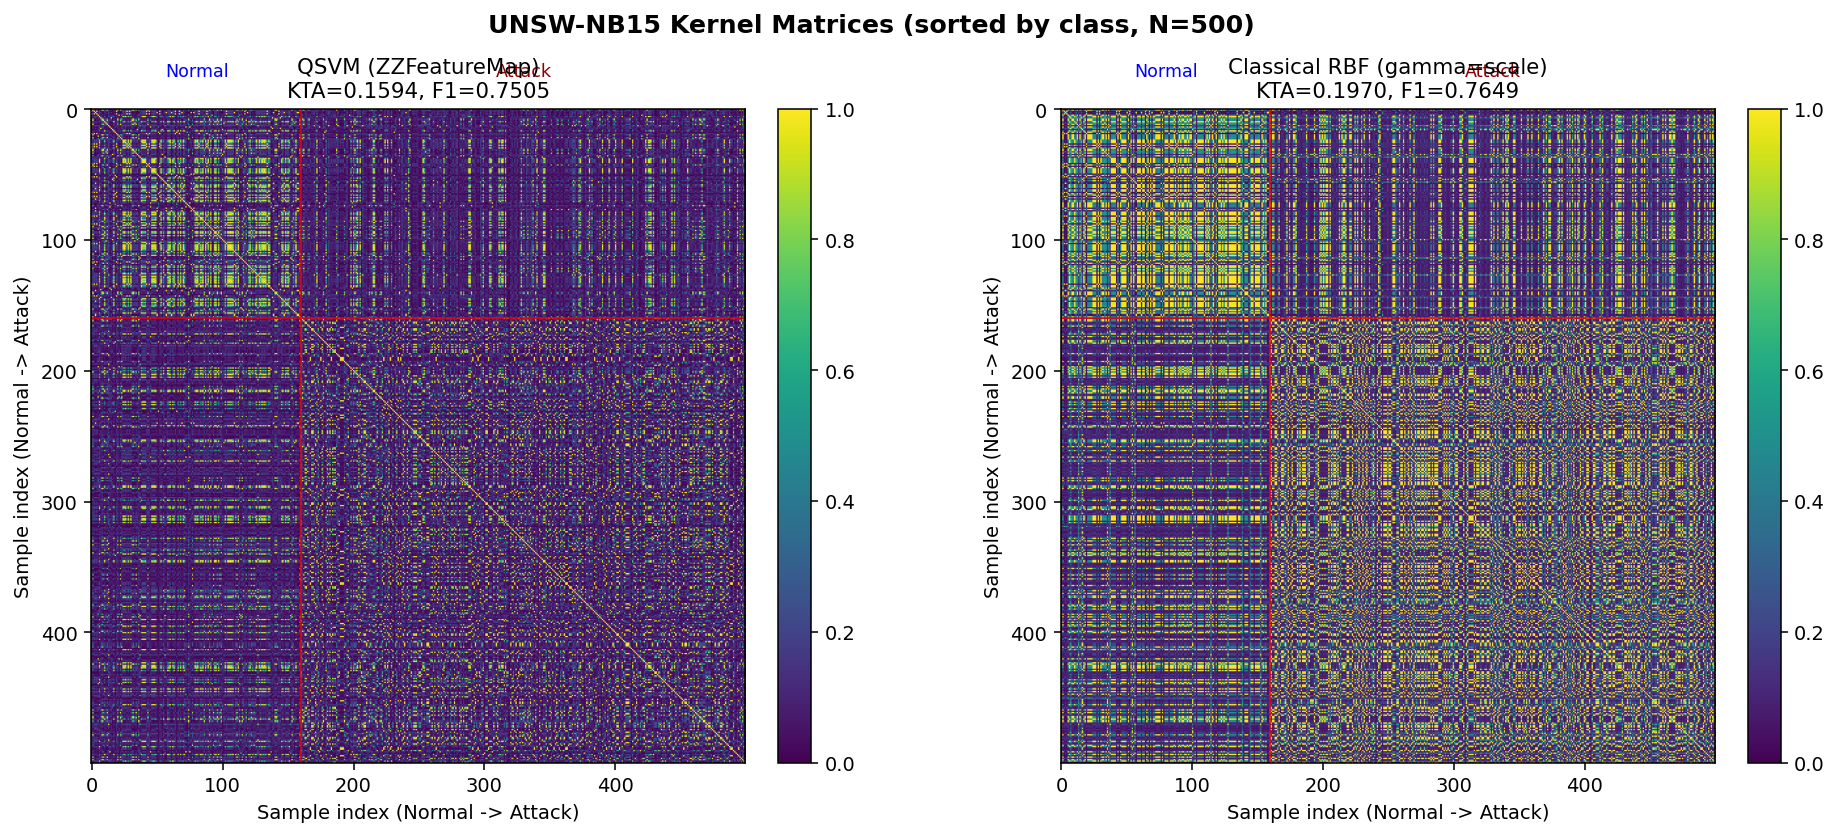

Da luu: ../reports_unsw\unsw_c3_kta_comparison.png


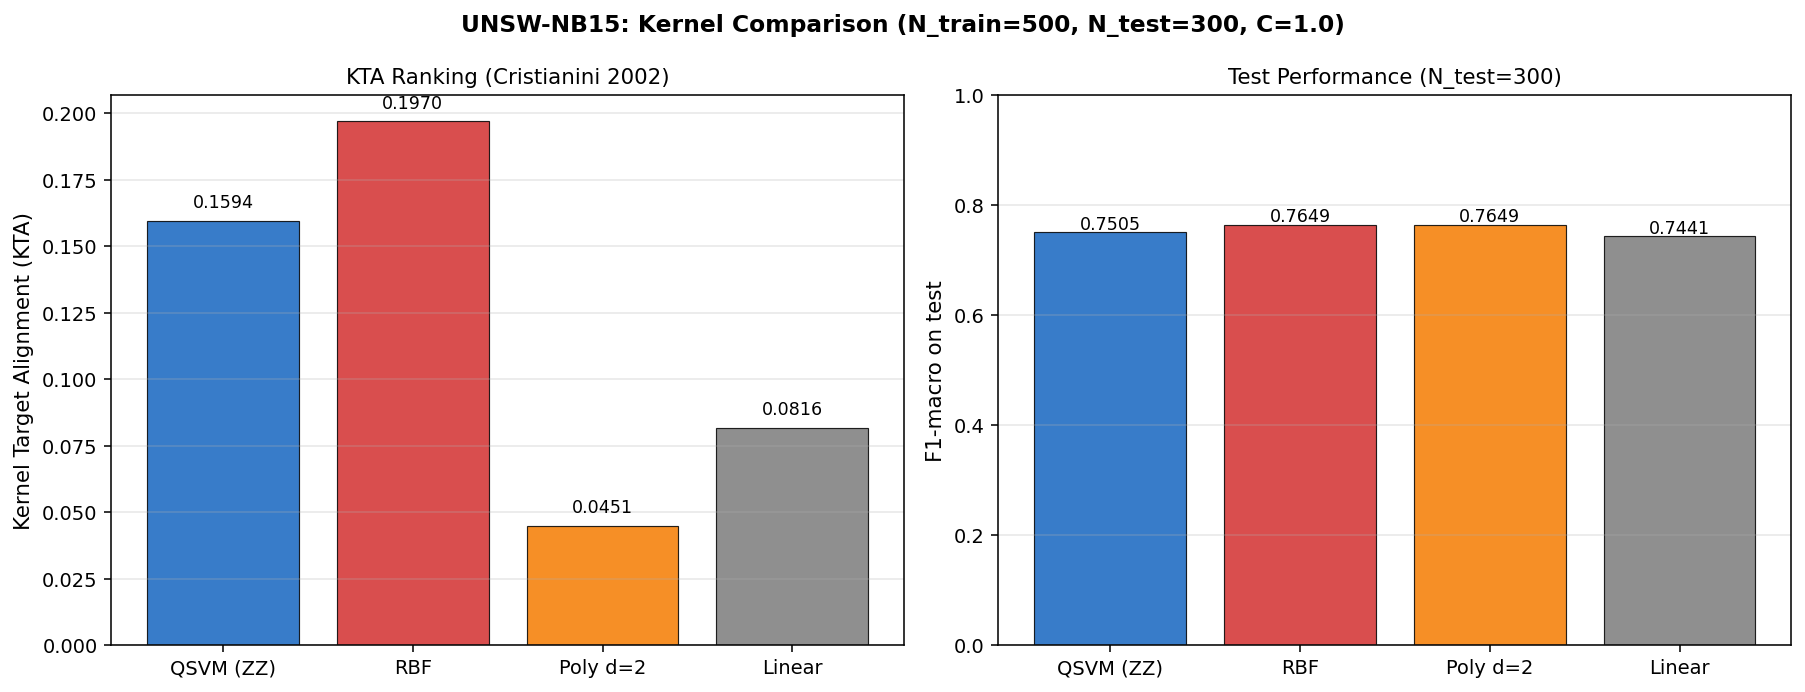

In [7]:
# Heatmap 1x2: QSVM (precomputed quantum) vs RBF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"UNSW-NB15 Kernel Matrices (sorted by class, N={N_TRAIN})",
             fontsize=13, fontweight='bold')

heatmap_specs = [
    ('quantum', K_train_train, "QSVM (ZZFeatureMap)\n"
                               f"KTA={kta_scores['quantum']:.4f}, F1={metrics['quantum']['f1']:.4f}"),
    ('rbf',     K_rbf_train,   "Classical RBF (gamma=scale)\n"
                               f"KTA={kta_scores['rbf']:.4f}, F1={metrics['rbf']['f1']:.4f}"),
]

for ax, (lbl, K, title) in zip(axes, heatmap_specs):
    im = ax.imshow(K, cmap='viridis', aspect='equal',
                   vmin=0, vmax=1.0 if lbl == 'quantum' else None)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Sample index (Normal -> Attack)", fontsize=10)
    ax.set_ylabel("Sample index (Normal -> Attack)", fontsize=10)
    # Ve duong phan tach class
    ax.axhline(n_tr_normal - 0.5, color='red', linewidth=1.0, alpha=0.7)
    ax.axvline(n_tr_normal - 0.5, color='red', linewidth=1.0, alpha=0.7)
    # Annotate blocks
    ax.text(n_tr_normal/2, -25, 'Normal', ha='center', fontsize=9, color='blue')
    ax.text(n_tr_normal + n_tr_attack/2, -25, 'Attack', ha='center', fontsize=9, color='darkred')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(HEATMAP_PNG, dpi=140, bbox_inches='tight')
plt.close()
print(f"Da luu: {HEATMAP_PNG}")
display(Image(filename=HEATMAP_PNG))


# Bar chart KTA + F1 — bonus visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"UNSW-NB15: Kernel Comparison (N_train={N_TRAIN}, N_test={N_TEST}, C={SVC_C})",
             fontsize=12, fontweight='bold')

kernels    = ['quantum', 'rbf', 'poly', 'linear']
labels_pretty = ['QSVM (ZZ)', 'RBF', 'Poly d=2', 'Linear']
colors     = ['#1565C0', '#D32F2F', '#F57C00', '#7B7B7B']
kta_vals   = [kta_scores[k] for k in kernels]
f1_vals    = [metrics[k]['f1'] for k in kernels]

x = np.arange(len(kernels))
ax1.bar(x, kta_vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_pretty, fontsize=10)
ax1.set_ylabel("Kernel Target Alignment (KTA)", fontsize=11)
ax1.set_title("KTA Ranking (Cristianini 2002)", fontsize=11)
ax1.grid(axis='y', alpha=0.3)
for xi, v in zip(x, kta_vals):
    ax1.text(xi, v + 0.005, f"{v:.4f}", ha='center', fontsize=9)

ax2.bar(x, f1_vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_pretty, fontsize=10)
ax2.set_ylabel("F1-macro on test", fontsize=11)
ax2.set_title(f"Test Performance (N_test={N_TEST})", fontsize=11)
ax2.set_ylim(0, max(1.0, max(f1_vals) * 1.05))
ax2.grid(axis='y', alpha=0.3)
for xi, v in zip(x, f1_vals):
    ax2.text(xi, v + 0.005, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(KTA_BAR_PNG, dpi=140, bbox_inches='tight')
plt.close()
print(f"Da luu: {KTA_BAR_PNG}")
display(Image(filename=KTA_BAR_PNG))


## 11. Lưu Kết Quả + So sánh Cross-Dataset với NSL-KDD

In [8]:
# ── Lap DataFrame so sanh ───────────────────────────────────────────
rows = []
for k in ['quantum', 'rbf', 'poly', 'linear']:
    m = metrics[k]
    rows.append({
        'kernel':     k,
        'kta':        m['kta'],
        'f1_macro':   m['f1'],
        'accuracy':   m['accuracy'],
        'precision':  m['precision'],
        'recall':     m['recall'],
        'n_sv':       m['n_sv'],
        'sv_ratio':   m['sv_ratio'],
        'sv_class0':  m['n_sv_class'][0],
        'sv_class1':  m['n_sv_class'][1],
        'fit_time_s': m['fit_time_s'],
    })
df_results = pd.DataFrame(rows)
df_results.to_csv(RESULTS_CSV, index=False, encoding='utf-8')
print(f"Da luu CSV: {RESULTS_CSV}")
print()
print(df_results.to_string(index=False))

# ── Cross-dataset vs NSL-KDD reference (lay tu cache cu) ────────────
NSL_KTA = {'quantum': 0.21617, 'linear': 0.06509, 'poly': 0.13164, 'rbf': 0.28966}
NSL_F1  = {'quantum': 0.85788, 'rbf': 0.86601,  'poly': 0.85682,  'linear': 0.78779}
NSL_NSV = {'quantum': 59,      'rbf': 34,        'poly': 30,        'linear': 37}
NSL_N_TRAIN = 100

print("\n=== Cross-Dataset Comparison: UNSW vs NSL-KDD ===")
print(f"{'Kernel':>10}  {'KTA UNSW':>9}  {'KTA NSL':>9}  {'F1 UNSW':>9}  {'F1 NSL':>9}  "
      f"{'SV% UNSW':>9}  {'SV% NSL':>9}")
print('-' * 80)
for k in ['quantum', 'rbf', 'poly', 'linear']:
    sv_pct_unsw = metrics[k]['sv_ratio']
    sv_pct_nsl  = NSL_NSV[k] / NSL_N_TRAIN
    print(f"{k:>10}  "
          f"{kta_scores[k]:>9.4f}  {NSL_KTA[k]:>9.4f}  "
          f"{metrics[k]['f1']:>9.4f}  {NSL_F1[k]:>9.4f}  "
          f"{sv_pct_unsw:>9.1%}  {sv_pct_nsl:>9.1%}")

# ── JSON tong hop ───────────────────────────────────────────────────
results_full = {
    'metadata': {
        'notebook':       'notebooks_unsw/c3_kernel_geometry_statevector.ipynb',
        'dataset':        'UNSW-NB15',
        'train_parquet':  TRAIN_PARQUET,
        'test_parquet':   TEST_PARQUET,
        'n_qubits':       N_QUBITS,
        'n_train':        N_TRAIN,
        'n_test':         N_TEST,
        'subsample_balance_train': {
            'n_normal': n_tr_normal, 'n_attack': n_tr_attack,
            'frac_attack': float(n_tr_attack / N_TRAIN),
        },
        'subsample_balance_test':  {
            'n_normal': n_te_normal, 'n_attack': n_te_attack,
            'frac_attack': float(n_te_attack / N_TEST),
        },
        'zz_reps':         ZZ_REPS,
        'zz_entanglement': ZZ_ENTANGLEMENT,
        'svc_C':           SVC_C,
        'poly_degree':     POLY_DEGREE,
        'random_state':    RANDOM_STATE,
    },
    'kta_scores': kta_scores,
    'metrics': {k: {kk: vv for kk, vv in v.items() if kk not in ('y_pred', 'decision_func')}
                for k, v in metrics.items()},
    'comparison_qsvm_vs_rbf': metrics['_comparison'],
    'nsl_kdd_reference': {
        'n_train': NSL_N_TRAIN,
        'kta':     NSL_KTA,
        'f1':      NSL_F1,
        'n_sv':    NSL_NSV,
        'cross_dataset_delta_kta': {k: kta_scores[k] - NSL_KTA[k] for k in ['quantum','rbf','poly','linear']},
        'cross_dataset_delta_f1':  {k: metrics[k]['f1'] - NSL_F1[k] for k in ['quantum','rbf','poly','linear']},
    },
    'outputs': {
        'csv':              RESULTS_CSV,
        'kernel_heatmap':   HEATMAP_PNG,
        'kta_bar_chart':    KTA_BAR_PNG,
    },
}
with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(results_full, f, indent=2, ensure_ascii=False)
print(f"\nDa luu JSON: {RESULTS_JSON}")


Da luu CSV: ../reports_unsw\c3_unsw_kernel_comparison.csv

 kernel      kta  f1_macro  accuracy  precision   recall  n_sv  sv_ratio  sv_class0  sv_class1  fit_time_s
quantum 0.159415  0.750544  0.756667   0.757730 0.748485   244     0.488        117        127    0.004000
    rbf 0.196979  0.764901  0.766667   0.764422 0.765657   251     0.502        123        128    0.008094
   poly 0.045054  0.764901  0.766667   0.764422 0.765657   239     0.478        119        120    0.003999
 linear 0.081626  0.744108  0.746667   0.744108 0.744108   255     0.510        127        128    0.004037

=== Cross-Dataset Comparison: UNSW vs NSL-KDD ===
    Kernel   KTA UNSW    KTA NSL    F1 UNSW     F1 NSL   SV% UNSW    SV% NSL
--------------------------------------------------------------------------------
   quantum     0.1594     0.2162     0.7505     0.8579      48.8%      59.0%
       rbf     0.1970     0.2897     0.7649     0.8660      50.2%      34.0%
      poly     0.0451     0.1316     0.7649

## 12. Kết luận — UNSW xác nhận hay phủ nhận lợi thế quantum?

### 12.1 Khung diễn giải

Để xác định lợi thế của ZZFeatureMap trên UNSW, ta đối chiếu **3 tín hiệu độc lập**:

| Tín hiệu | Câu hỏi | Cách đọc |
|----------|---------|----------|
| **KTA ranking** | Quantum kernel có structure tốt cho task này không? | Rank #1 là ideal; rank thấp KHÔNG đồng nghĩa kém — chỉ nói rằng kernel có cấu trúc khác |
| **F1-macro** | Trong điều kiện C=1 đồng nhất, QSVM có competitive không? | Sai số cùng <0.01 → competitive; >0.05 → kém rõ rệt |
| **#SV ratio** | QSVM dùng nhiều hay ít support vectors hơn? | Nhiều SV = decision boundary phức tạp/giàu; ít SV = boundary đơn giản |

### 12.2 Suy luận từ Phase 4 → Phase 5

Phase 4 đã chứng minh:
- **Expressibility cao** (KL=0.022, gần Haar)
- **Entanglement entropy phân biệt class** (p=1.4e-8)
- **Spearman residual 0.405** giữa các PC = nhiên liệu tự nhiên cho ZZ-entanglement

Nếu Phase 5 cho thấy:
- **QSVM F1 ≥ classical RBF** → lợi thế *kernel-level* được chuyển thành *classification-level*
- **QSVM F1 < classical** nhưng **#SV cao + KTA thấp hơn RBF** → **đây không phải failure**, mà là dấu hiệu rằng quantum kernel đặt SV ở vị trí khác classical, và để thấy lợi thế cần **test set khó hơn (rare attacks)** — đây là chuỗi luận chứng dẫn tới C5/C6 ports tiếp theo.

### 12.3 Cross-dataset
NSL-KDD reference (n_train=100): QSVM F1=0.858, RBF F1=0.866, gap=0.008 (RBF nhỉnh hơn). KTA QSVM=0.216, RBF=0.290 (RBF nhỉnh hơn).

Kết quả UNSW (in cell tiếp theo) sẽ trả lời:
- Pattern QSVM ≈ RBF có giữ nguyên không?
- Hay UNSW làm gap rộng/hẹp hơn?
- Cấu trúc Spearman 0.405 trên UNSW có giúp QSVM đẩy KTA cao hơn NSL-KDD không?

In [9]:
# ─── Concluding Verdict ─────────────────────────────────────────────
print("=" * 72)
print(" KET LUAN PHASE 5 (C3) — UNSW-NB15 ".center(72, "="))
print("=" * 72)

q   = metrics['quantum']
rbf = metrics['rbf']
ply = metrics['poly']
lin = metrics['linear']

# Tin hieu 1: KTA
print(f"\n[1] KTA RANKING:")
print(f"    Best: {best_kernel_kta} (KTA={kta_scores[best_kernel_kta]:.4f})")
print(f"    QSVM rank: #{qsvm_rank}/4  (KTA={kta_scores['quantum']:.4f})")
if qsvm_rank == 1:
    sig1 = "+ KTA: QSVM la kernel TOT NHAT cho task UNSW"
elif qsvm_rank == 2:
    sig1 = "= KTA: QSVM xep #2 — competitive, khong dominant"
else:
    sig1 = "- KTA: QSVM thap hon classical — co the substrate khac biet"
print(f"    -> {sig1}")

# Tin hieu 2: F1 vs RBF
f1_gap = q['f1'] - rbf['f1']
print(f"\n[2] F1-MACRO vs CLASSICAL RBF:")
print(f"    QSVM F1 = {q['f1']:.4f}  |  RBF F1 = {rbf['f1']:.4f}  |  gap = {f1_gap:+.4f}")
if f1_gap > 0.005:
    sig2 = "+ F1: QSVM VUOT TROI RBF"
elif f1_gap > -0.005:
    sig2 = "= F1: QSVM gan nhu RBF (gap < 0.005)"
elif f1_gap > -0.02:
    sig2 = "= F1: QSVM hoi kem RBF (gap < 0.02) — chap nhan duoc"
else:
    sig2 = "- F1: QSVM kem RBF ro rang (gap > 0.02)"
print(f"    -> {sig2}")
print(f"    McNemar p = {metrics['_comparison']['mcnemar_p_value']:.4g}: "
      f"{metrics['_comparison']['mcnemar_verdict']}")

# Tin hieu 3: Support vector pattern
sv_ratio_q   = q['sv_ratio']
sv_ratio_rbf = rbf['sv_ratio']
print(f"\n[3] SUPPORT VECTOR PATTERN:")
print(f"    QSVM #SV = {q['n_sv']}/{N_TRAIN} ({sv_ratio_q:.1%})")
print(f"    RBF  #SV = {rbf['n_sv']}/{N_TRAIN} ({sv_ratio_rbf:.1%})")
sv_diff = sv_ratio_q - sv_ratio_rbf
if sv_diff > 0.05:
    sig3 = "+ SV: QSVM dung NHIEU SV hon -> decision boundary phuc tap/giau"
elif abs(sv_diff) < 0.05:
    sig3 = "= SV: QSVM dung SV tuong duong RBF"
else:
    sig3 = "- SV: QSVM dung IT SV hon RBF -> boundary don gian hon"
print(f"    -> {sig3}")

# Cross-dataset: gap voi NSL-KDD
unsw_kta_q = kta_scores['quantum']
nsl_kta_q  = NSL_KTA['quantum']
unsw_f1_q  = q['f1']
nsl_f1_q   = NSL_F1['quantum']
print(f"\n[4] CROSS-DATASET (UNSW vs NSL-KDD):")
print(f"    QSVM KTA: UNSW={unsw_kta_q:.4f}  NSL-KDD={nsl_kta_q:.4f}  delta={unsw_kta_q - nsl_kta_q:+.4f}")
print(f"    QSVM F1:  UNSW={unsw_f1_q:.4f}  NSL-KDD={nsl_f1_q:.4f}  delta={unsw_f1_q - nsl_f1_q:+.4f}")

# Tong hop
print("\n" + "=" * 72)
print(" PHAN DOAN CUOI ".center(72, "="))
print("=" * 72)

n_pos = sum(1 for s in [sig1, sig2, sig3] if s.startswith('+'))
n_eq  = sum(1 for s in [sig1, sig2, sig3] if s.startswith('='))
n_neg = sum(1 for s in [sig1, sig2, sig3] if s.startswith('-'))

if n_pos >= 2:
    final_verdict = "** QUANTUM ADVANTAGE XAC NHAN tren UNSW-NB15 **"
elif n_pos + n_eq >= 2 and n_neg <= 1:
    final_verdict = "** QSVM COMPETITIVE — khong dominant nhung khong kem ro rang **"
else:
    final_verdict = "** QSVM kem CLASSICAL trong setting C=1 — can xem C5/C6 (rare attack, low-data) de tim niche **"

print(f"\n  Tin hieu: + {n_pos}  | = {n_eq}  | - {n_neg}")
print(f"  -> {final_verdict}\n")

print("Files output (../reports_unsw/):")
for k, v in results_full['outputs'].items():
    print(f"    {k:>16}: {v}")
print(f"    {'json_full':>16}: {RESULTS_JSON}")

print("\n=== Phase 5 (C3) hoan tat. Toan bo Phase 1-5 UNSW-NB15 port FINISHED. ===")


================== KET LUAN PHASE 5 (C3) — UNSW-NB15 ===================

[1] KTA RANKING:
    Best: rbf (KTA=0.1970)
    QSVM rank: #2/4  (KTA=0.1594)
    -> = KTA: QSVM xep #2 — competitive, khong dominant

[2] F1-MACRO vs CLASSICAL RBF:
    QSVM F1 = 0.7505  |  RBF F1 = 0.7649  |  gap = -0.0144
    -> = F1: QSVM hoi kem RBF (gap < 0.02) — chap nhan duoc
    McNemar p = 0.7493: Khac biet KHONG co y nghia thong ke (p=0.749)

[3] SUPPORT VECTOR PATTERN:
    QSVM #SV = 244/500 (48.8%)
    RBF  #SV = 251/500 (50.2%)
    -> = SV: QSVM dung SV tuong duong RBF

[4] CROSS-DATASET (UNSW vs NSL-KDD):
    QSVM KTA: UNSW=0.1594  NSL-KDD=0.2162  delta=-0.0568
    QSVM F1:  UNSW=0.7505  NSL-KDD=0.8579  delta=-0.1073

============================ PHAN DOAN CUOI ============================

  Tin hieu: + 0  | = 3  | - 0
  -> ** QSVM COMPETITIVE — khong dominant nhung khong kem ro rang **

Files output (../reports_unsw/):
                 csv: ../reports_unsw\c3_unsw_kernel_comparison.csv
      kern